# ***Model training***

Using the scripts inside `src` directory we can perform any kind of experiment starting from data generation to model evaluation, and drift detection(data, target, concept)

- To maintain consistancy in filenames(csv, model, threashold, html, png) I have included a seed number during data generation, and it will be there in every filename only if you generate a dataset or use an existing dataset the naming would be for example `filename_seed_xx`.


- Generated the data will be stored inside the `data/simulated` and features will be stored in `data/features` directory.

- Models will stored in `artifacts/models` and thresholds will be inside `artifacts/model_threshold` directory.

- Execute the scripts in the following order, don't change it. But it possible to change the parameters of the functions.

## 1. Generate the data for training
This is where all starts, this function will generate 10_000 transactions of 500 users, with a seed number 42 by default. Change the `seed` parameter to get different dataset. It is also possible to change the number of transactions and users.

In [1]:
from fraud_detection import generate_transactions_data 

df = generate_transactions_data()
df.head()

Name of the csv file: 'simulated_transactions_seed_42.csv'

Data saved to: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/data/simulated

Generated 10000 transactions.
Fraud rate: 1.48%


,tx_id,timestamp,user_id,amount,category,device_id,auth_method,lat,lon,ip_address,is_fraud
0,e4fd6c34-d67,2026-01-18 06:53:16.569162,user_55,172.43,grocery,475287aa,PIN,-83.615968,174.348649,120.185.31.102,0
1,0cb5ee5c-62f,2026-01-17 09:52:36.654372,user_407,8.43,food,379d58f9,Biometric,20.500359,150.789724,107.109.217.82,0
2,39a0f145-a5b,2026-02-11 06:43:37.486858,user_142,1259.07,tech,bea29dfe,PIN,-87.864685,123.877867,145.56.170.82,0
3,052226b9-836,2026-01-15 12:45:16.326726,user_492,26.14,grocery,052dfb9a,Biometric,-0.992383,-52.469217,208.72.228.108,0
4,a5ba2472-21d,2026-01-25 01:15:38.754994,user_261,364.83,utilities,0d18ab95,Biometric,8.142126,36.488989,104.34.170.221,0


## 2. Perform feature engineering
Just take the name of the csv file with quotes from above cell output and use it as a parameter in feature engineering function, and you will get the model ready features.

In [2]:
from fraud_detection import feature_engineering

df = feature_engineering(
    'simulated_transactions_seed_42.csv'
)

df.head()

Name of the csv file: 'fraud_features_seed_42.csv'

Features saved at: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/data/features

No of rows: 10000
No of columns: 18


,amount,lat,lon,is_fraud,hour,day_of_week,tx_count_24h,avg_spend_user,amount_ratio,dist_from_last_tx_km,travel_velocity_kmph,auth_method_PIN,auth_method_Password,category_food,category_grocery,category_tech,category_travel,category_utilities
0,347.15,81.605220,-120.226604,0,13,0,1.0,0.000000,0.000000,0.000000,0.0,False,False,False,False,False,False,True
1,232.72,81.664590,-120.236689,0,13,1,2.0,347.150000,0.670373,6.603658,0.0,True,False,False,False,False,False,True
2,260.47,81.612479,-120.228856,0,21,1,2.0,289.935000,0.898374,5.795863,0.0,False,True,False,False,False,False,True
3,103.94,81.600013,-120.252652,0,11,2,3.0,280.113333,0.371064,1.438964,0.0,False,False,True,False,False,False,False
4,2897.77,81.599709,-120.249781,0,1,3,2.0,236.070000,12.275046,0.057599,0.0,False,True,False,False,True,False,False


## 3. Model Training

- Just take the name of the csv file with quotes from above cell output and use it as a parameter in `model_trainer` function.

- `model_trainer` function will return two output one is testing features `X_test` and other one is target `y_test`, keep them for further use. **Don't worry your model(s) will be trained, just click on the directory, you will see it.**

- This `X_test` and `y_test` are holds the default meaning it generally hold (`train_test_split`).

- Currently there are two algo in the `config.yaml` file, `RandomForestClassifier` and `XGBClassifier`. The script will perform a grid serach so it may take some time. Also it is possible to add another algo in the `config.yaml` file. 

In [3]:
from fraud_detection import model_trainer

X_test, y_test = model_trainer(
    'fraud_features_seed_42.csv'
)

Running GridSearch for: random_forest
Model Name: 'random_forest_seed_42.json'
Best Score: 0.9992 | Saved to: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/artifacts/models
Running GridSearch for: xgboost
Model Name: 'xgboost_seed_42.json'
Best Score: 0.9981 | Saved to: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/artifacts/models


## 4. Business-cost-aware Thresholding (Threshold Optimization) 
Q. Why is this necessary?

A. Not catching a fraud is much more deadly than blocking a legitamite transaction. ***Considering them as equal, is like commiting warcrimes on our customers***.

Inevitably, xgboost treats both of these errors equally because of it's fixed threshold 0.5, ***going down that path would lead us to loose money and trust***. 

So we need a custom decision boundary that ***prioritize catching fraud***.

- The variables you put above will be used here in this function `threshold_optimizer` as a parameter.

- `threshold_optimizer` will return two values, first one is probability of that particular model on test data, the second one is using the threshold make a final prediction. Put this two values inside two variables. But don't just use `y_prob` and `y_pred_final` as variable name. Just put the the name of the model after underscore `_`. 

- Now this two new variable and the previous two variable will be used to evaluate a model.


### a. Optimize threshold xgboost

In [4]:
from fraud_detection import threshold_optimizer

y_prob_xgb , y_pred_final_xgb = threshold_optimizer(
    X_test, 
    y_test, 
    'xgboost_seed_42.json'    
)

Optimal threshold information saved to: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/artifacts/model_thresholds

The threshold for the model: xgboost_seed_42 is: 0.97


### b. Optimize threshold RandomForest

In [5]:
from fraud_detection import threshold_optimizer

y_prob_rf , y_pred_final_rf = threshold_optimizer(
    X_test,
    y_test,
    'random_forest_seed_42.json'
)

Optimal threshold information saved to: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/artifacts/model_thresholds

The threshold for the model: random_forest_seed_42 is: 0.39


## 5. Model Evaluation

### a. Evaluate the xgboost model

AUC-PR for xgboost_seed_42.json: 1.0000

Classification Report for xgboost_seed_42.json:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



/home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/src/fraud_detection/model_evaluation.py:123: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  


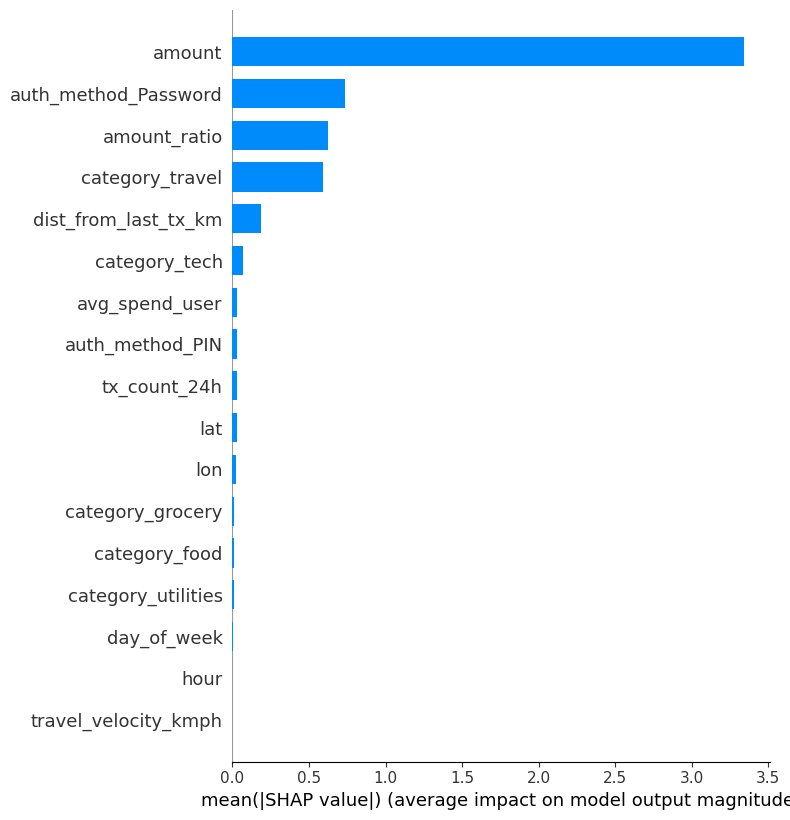

In [6]:
from fraud_detection import model_evaluator

model_evaluator(
    'xgboost_seed_42.json',
    X_test,
    y_test,
    y_prob_xgb,
    y_pred_final_xgb
)

### b. Evaluate the RandomForest Model

AUC-PR for random_forest_seed_42.json: 1.0000

Classification Report for random_forest_seed_42.json:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



/home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/src/fraud_detection/model_evaluation.py:123: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  


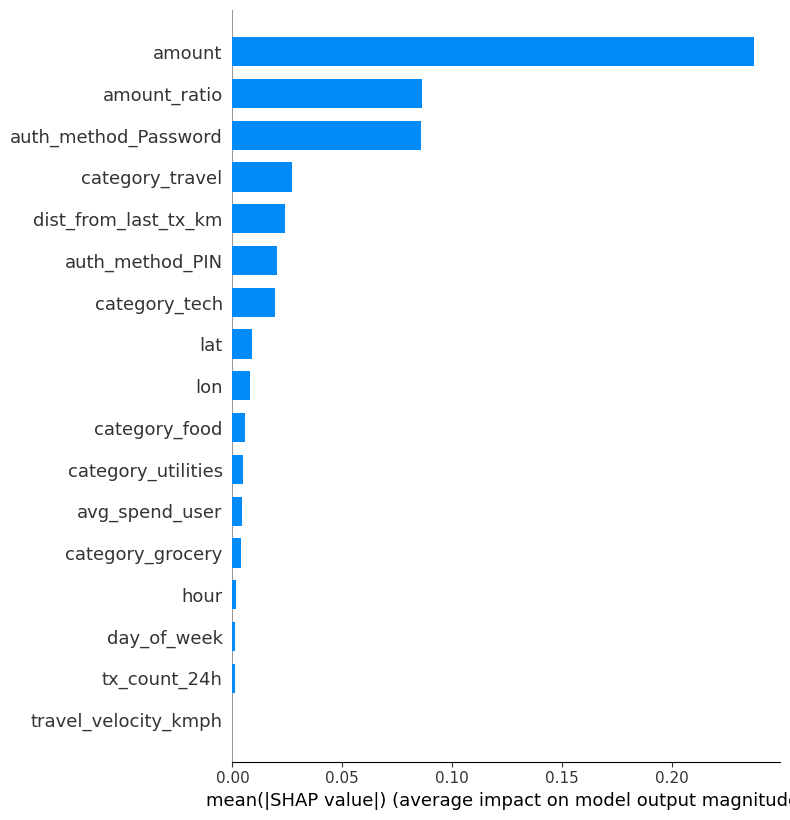

In [7]:
from fraud_detection import model_evaluator

model_evaluator(
    'random_forest_seed_42.json',
    X_test,
    y_test,
    y_prob_rf,
    y_pred_final_rf
)

# ***Testing on a new dataset***

Generate a new dataset with a seed no 69 and evaluate our models

## a. Data generation

In [8]:
from fraud_detection import generate_transactions_data 

df_new = generate_transactions_data(
    seed=69
)
df_new.head()

Name of the csv file: 'simulated_transactions_seed_69.csv'

Data saved to: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/data/simulated

Generated 10000 transactions.
Fraud rate: 1.48%


,tx_id,timestamp,user_id,amount,category,device_id,auth_method,lat,lon,ip_address,is_fraud
0,f9744aec-2a6,2026-02-01 23:04:40.250821,user_427,222.96,entertainment,9cc4db65,Biometric,65.893603,-148.365495,113.66.251.143,0
1,cbabf0a8-f1c,2026-01-10 08:29:08.889936,user_262,136.53,food,d438044a,Password,31.419059,165.176342,23.232.214.17,0
2,e65c2a77-6bd,2026-02-08 20:02:38.574839,user_162,78.84,grocery,98385fe7,Biometric,54.196309,3.579783,53.76.204.35,0
3,226d78a1-36a,2026-01-13 03:22:14.563369,user_267,73.00,utilities,1cdf4a65,Biometric,-42.986678,107.731463,115.65.179.248,0
4,682a4572-c28,2026-01-03 07:09:56.359699,user_276,354.15,entertainment,9d545db5,PIN,81.356313,-151.038827,9.161.1.194,0


## ***Drift detection***

Before we do anything, let's just check if there was any data drift present between the trained data and newly generated data.

In [9]:
from operator import ge
from fraud_detection import generate_monitoring_report

drift_stats = generate_monitoring_report(
    model_name= 'xgboost_seed_42.json',
    trained_dataset= 'simulated_transactions_seed_42.csv',
    new_dataset= 'simulated_transactions_seed_69.csv'
)



TypeError: ('Expecting data to be a DMatrix object, got: ', <class 'pandas.DataFrame'>)

## b. Feature Engineering

In [ ]:
from fraud_detection import feature_engineering

df_new = feature_engineering(
    'simulated_transactions_seed_69.csv'
)

df_new.head()

Name of the csv file: 'fraud_features_seed_69.csv'

Saved at: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/data/features/fraud_features_seed_69.csv

No of rows: 10000
No of columns: 18


,amount,lat,lon,is_fraud,hour,day_of_week,tx_count_24h,avg_spend_user,amount_ratio,dist_from_last_tx_km,travel_velocity_kmph,auth_method_PIN,auth_method_Password,category_food,category_grocery,category_tech,category_travel,category_utilities
0,167.52,-80.018972,-128.503529,0,18,5,1.0,0.000000,0.000000,0.000000,0.0,False,False,False,True,False,False,False
1,75.89,-79.978198,-128.498238,0,9,6,2.0,167.520000,0.453021,4.535013,0.0,True,False,False,False,False,False,False
2,69.39,-79.942544,-128.543715,0,8,0,2.0,121.705000,0.570149,4.061371,0.0,False,False,False,False,False,False,False
3,614.22,-79.940534,-128.549401,0,6,1,2.0,104.266667,5.890857,0.249293,0.0,False,False,False,False,True,False,False
4,45.89,-79.960488,-128.532205,0,5,2,2.0,231.755000,0.198011,2.243731,0.0,True,False,True,False,False,False,False


## c. Threshold optimization

Before threshold optimization, we need to separate the **features** from the **target**.

### For xgboost

In [ ]:
# Keeping the naming convention
X_test = df.drop(columns=['is_fraud'])
y_test = df['is_fraud']

In [ ]:
from fraud_detection import threshold_optimizer

y_prob_xgb, y_pred_final_xgb = threshold_optimizer(
    X_test=X_test,
    y_test=y_test,
    model_name='xgboost_seed_42.json'
)


Optimal threshold information saved to: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/artifacts/model_thresholds

The threshold for the model: xgboost_seed_42 is: 0.9400000000000001


AUC-PR for xgboost_seed_42.json: 1.0000

Classification Report for xgboost_seed_42.json:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



/home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/src/fraud_detection/model_evaluation.py:123: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  


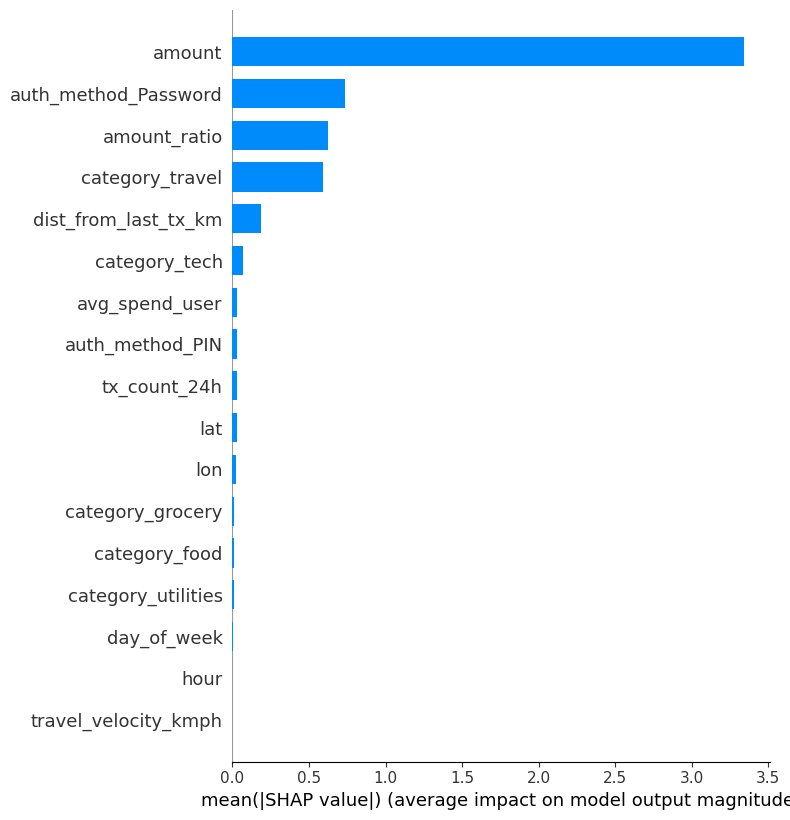

In [10]:
from fraud_detection import model_evaluator

model_evaluator(
    model_name='xgboost_seed_42.json',
    X_test=X_test,
    y_test=y_test,
    y_prob=y_prob_xgb,
    y_pred_final=y_pred_final_xgb
)